# Strategy lab (curated)

Loads `finTs`, then backtests **long-only** sleeves that did well on this universe: equal weight, trend (`Dist_SMA50` ranks), and **Păuna (2020) volume cyclicity** (XOR gate on VOC).

**Removed:** six market-neutral cross-sectional `FinStrat` paths (leaderboard, `FinTrade` on best cross-section) — they were weak on the same sample. Restore from git if you want them back.

**Flow:** data + QA → trend alpha → long-only backtests + execution dry-run.


In [16]:
import urllib3
from curl_cffi import requests

import jax.numpy as jnp
import numpy as np
import pandas as pd

from src.algorithm import FinBT, FinStrat, cross_section as xs
from src.algorithm.decision import DecisionContext
from src.algorithm.fintrade import FinTrade
from src.utils import indicators as ind
from unittest.mock import MagicMock

from src.data.fints import finTs

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
session = requests.Session(impersonate="chrome", verify=False)

START, END = "2022-01-01", "2025-01-01"
TICKERS = [
    "AAPL", "MSFT", "NVDA", "GOOGL", "AMZN", "META",
    "JPM", "XOM", "UNH", "PG", "KO", "ORCL",
]

data = finTs(
    start_date=START,
    end_date=END,
    ticker_list=TICKERS,
    session=session,
)

assert not data.df.empty, "No market data loaded. Check symbols and date range."
qa = data.qa_diagnostics(max_stale_days=15)
print("QA:", qa.as_dict())

data.df.head()

QA: {'duplicate_rows': 0, 'missing_ticker_dates': 0, 'stale_days_from_last_date': 459, 'invalid_ohlcv_rows': 0, 'warnings': ['stale_days_exceeds_limit days=459 limit=15']}


Price                    Open        High         Low       Close     Volume  \
Ticker Date                                                                    
AAPL   2022-01-03  174.013372  178.954991  173.895953  178.103653  104487900   
       2022-01-04  178.710370  179.013714  175.275693  175.843246   99310400   
       2022-01-05  175.755193  176.303172  170.891858  171.165848   94537600   
       2022-01-06  168.993445  171.537649  167.956198  168.308472   96904000   
       2022-01-07  169.179433  170.402605  167.359351  168.474884   86709100   

Price              SMA_50  SMA_200    RSI_14      MACD  MACD_Signal  ...  \
Ticker Date                                                          ...   
AAPL   2022-01-03     NaN      NaN       NaN  0.000000     0.000000  ...   
       2022-01-04     NaN      NaN  0.000000 -0.050714    -0.028175  ...   
       2022-01-05     NaN      NaN  0.000000 -0.209666    -0.102556  ...   
       2022-01-06     NaN      NaN  0.000000 -0.379986    -0.196537  ...   
       2022-01-07     NaN      NaN  1.921053 -0.457914    -0.274291  ...   

Price              Dist_SMA50  Dist_SMA200  BB_Width  BB_Position  MACD_Hist  \
Ticker Date                                                                    
AAPL   2022-01-03         NaN          NaN       NaN          NaN   0.000000   
       2022-01-04         NaN          NaN       NaN          NaN  -0.022540   
       2022-01-05         NaN          NaN       NaN          NaN  -0.107110   
       2022-01-06         NaN          NaN       NaN          NaN  -0.183450   
       2022-01-07         NaN          NaN       NaN          NaN  -0.183624   

Price              ATR_Norm  Vol_Change      Sector              Industry  \
Ticker Date                                                                 
AAPL   2022-01-03       NaN    0.000000  Technology  Consumer Electronics   
       2022-01-04       NaN   -0.049551  Technology  Consumer Electronics   
       2022-01-05       NaN   -0.048059  Technology  Consumer Electronics   
       2022-01-06       NaN    0.025031  Technology  Consumer Electronics   
       2022-01-07       NaN   -0.105206  Technology  Consumer Electronics   

Price                       SubIndustry  
Ticker Date                              
AAPL   2022-01-03  consumer-electronics  
       2022-01-04  consumer-electronics  
       2022-01-05  consumer-electronics  
       2022-01-06  consumer-electronics  
       2022-01-07  consumer-electronics  

[5 rows x 25 columns]

In [17]:
# Used by long-only trend sleeve (`neutralization="none"` — ranks stay nonnegative).


def alpha_trend_vs_sma50(panel: jnp.ndarray) -> jnp.ndarray:
    return xs.rank(panel[:, ind.IX_LIVE.DIST_SMA50])


## Long-only sleeves

`neutralization="none"` with nonnegative scores yields long-only targets. **Păuna VOC XOR** writes `data.df["Pauna_VOC_XOR"]` so the panel can carry the daily gate.


Long-only target sign check:
  Long-only equal weight: OK — no negative targets in sampled dates.
  Long-only trend (Dist_SMA50): OK — no negative targets in sampled dates.
  Long-only Păuna VOC XOR: OK — no negative targets in sampled dates.

Long-only backtest summary (sorted by total return):
                    strategy     end_value  total_return_pct  max_drawdown_pct  sharpe_ratio  avg_turnover_pct
Long-only trend (Dist_SMA50) 431078.262145         76.797229         13.527932      1.778850         10.765838
      Long-only equal weight 337003.862662         52.177703         26.332916      0.757523          0.899475
     Long-only Păuna VOC XOR 301057.121776         40.898265         26.284580      0.662669         26.852646


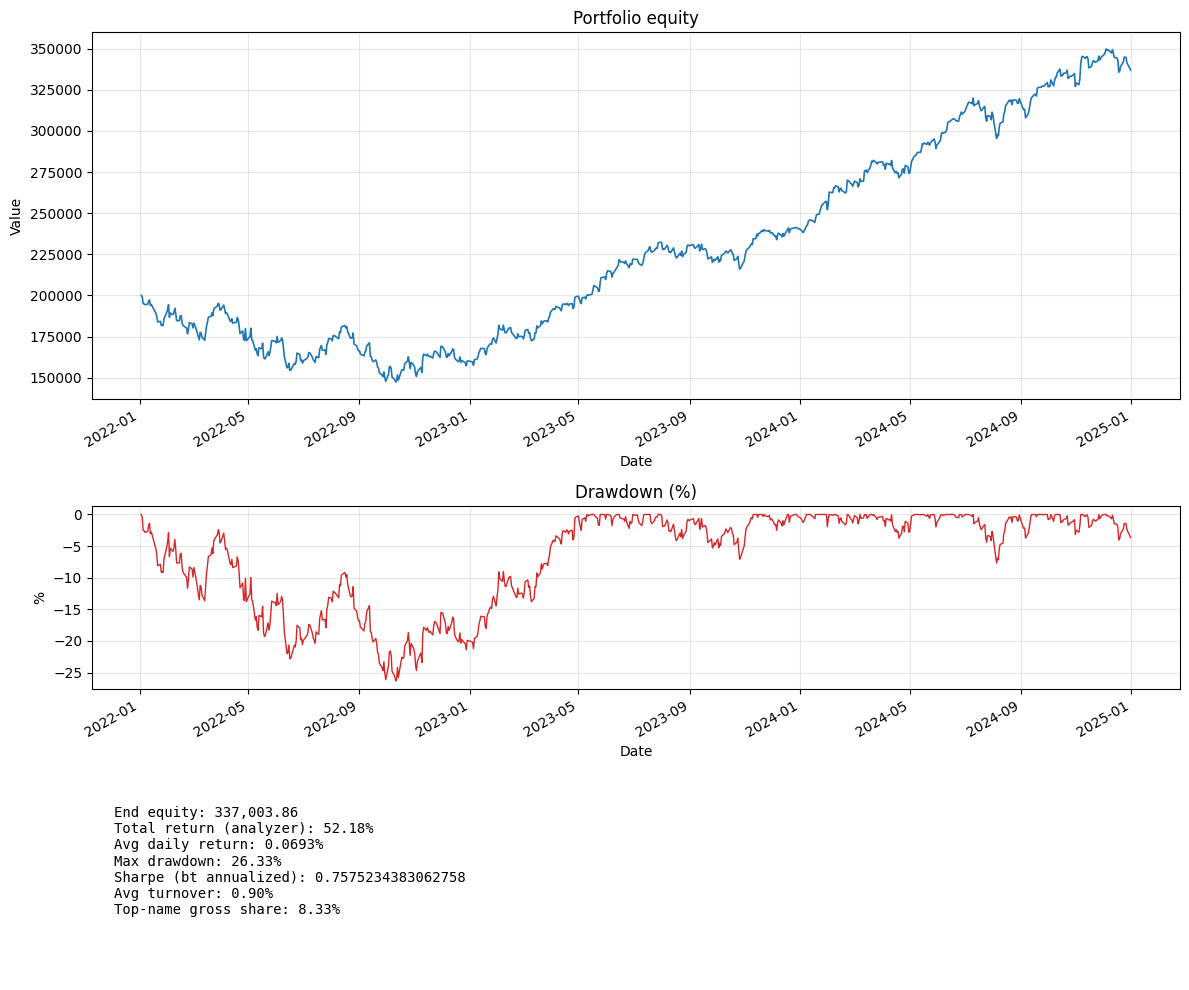

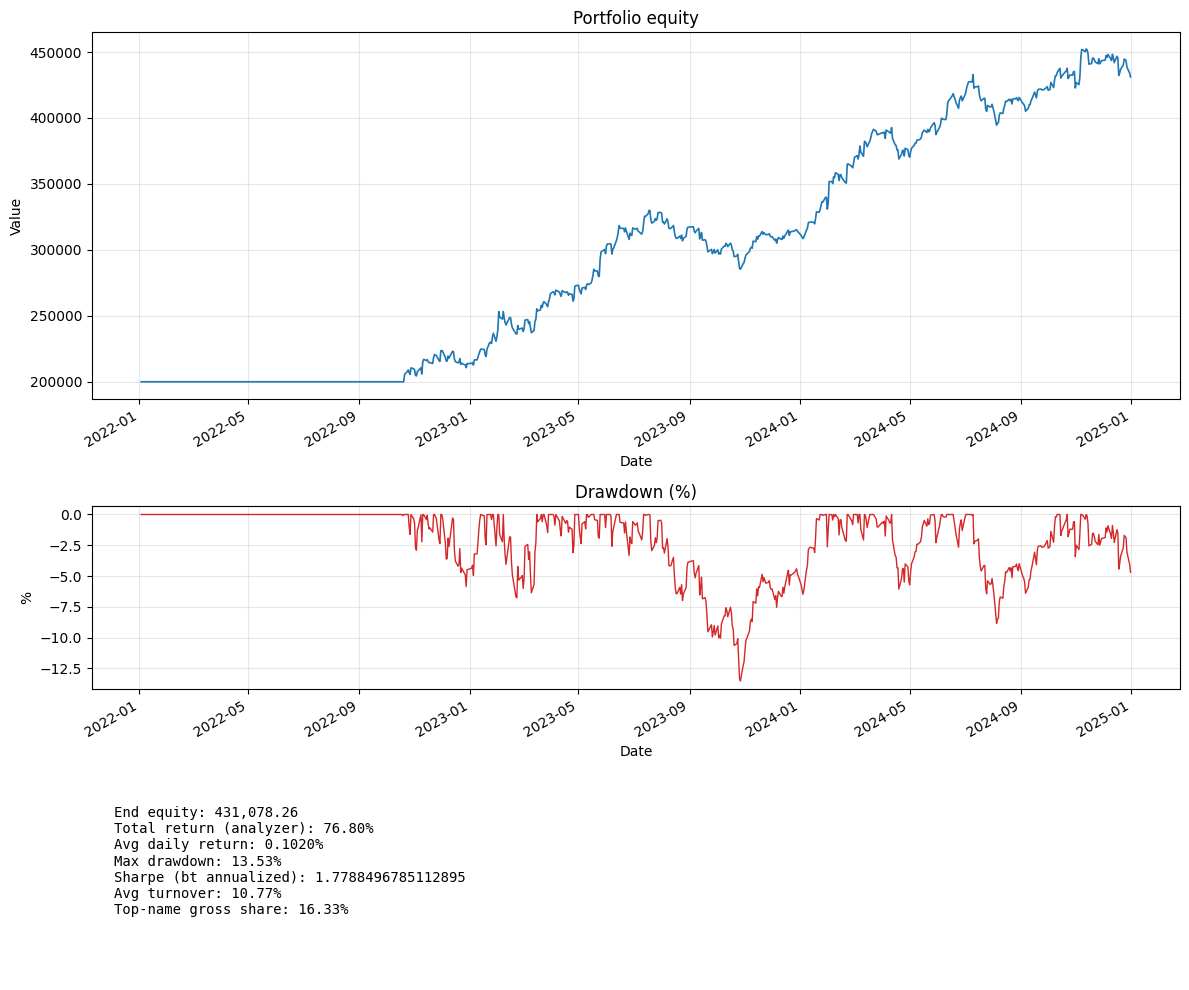

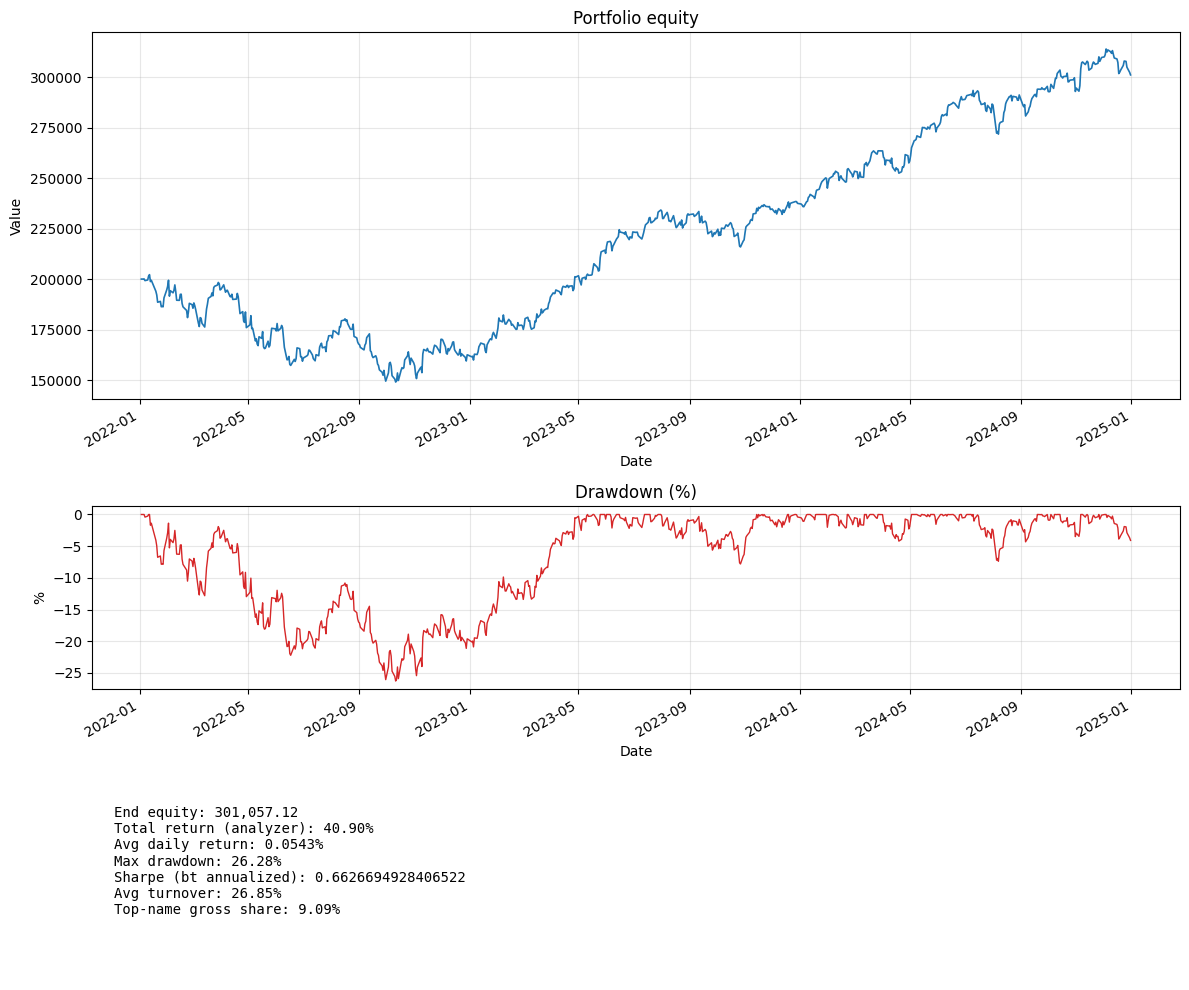

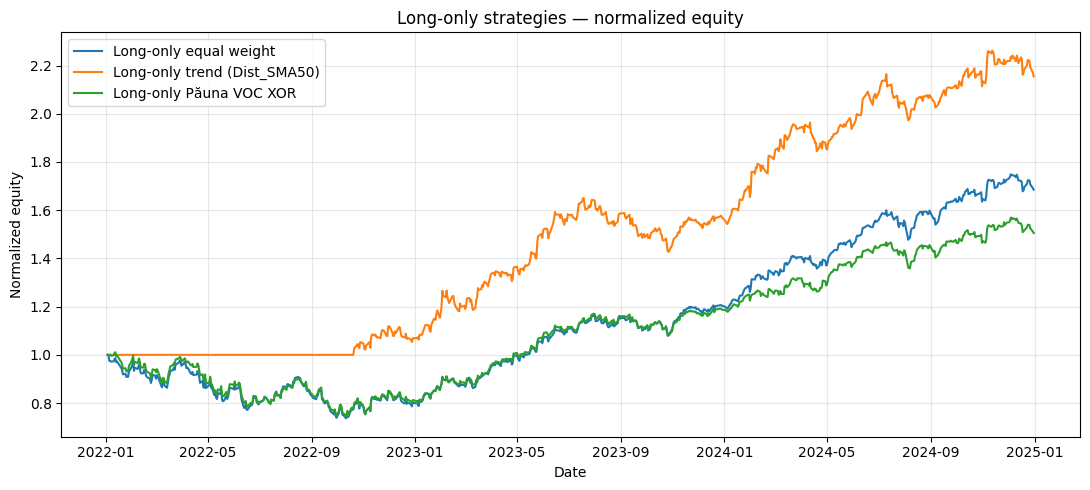

FinTrade dry-run (trend long-only): all targets ≥ 0 12 order rows


In [18]:
# Long-only + Păuna VOC XOR. Depends: prior cells (`data`, `FinStrat`, …).

from unittest.mock import MagicMock

PAUNA_VOC_PARAMS = {
    "p": 10,
    "P": 30,
    "n": 10,
    "alpha_smooth": 0.33,
    "delta_flat_default": 0.5,
}


def _pauna_voc_from_volume(
    volume: pd.Series,
    *,
    p: int,
    P: int,
    n: int,
    alpha_smooth: float,
    delta_flat_default: float = 0.5,
) -> np.ndarray:
    vol = volume.astype(float)
    im = vol.rolling(int(p), min_periods=int(p)).mean()
    iM = vol.rolling(int(P), min_periods=int(P)).mean()
    xi = im - iM
    D = iM - im
    mn = D.rolling(int(n), min_periods=int(n)).min()
    mx = D.rolling(int(n), min_periods=int(n)).max()
    denom = mx - mn
    delta = (mx - xi) / denom.replace(0.0, np.nan)
    delta = delta.fillna(float(delta_flat_default))
    d_arr = delta.to_numpy(dtype=float)
    voc = np.zeros(len(d_arr), dtype=float)
    a = float(alpha_smooth)
    for i in range(1, len(d_arr)):
        voc[i] = a * (d_arr[i] - voc[i - 1]) + voc[i - 1]
    return voc


def _buy_voc_xor(voc: np.ndarray) -> np.ndarray:
    sig = np.zeros(len(voc), dtype=bool)
    for i in range(2, len(voc)):
        sig[i] = (voc[i - 2] > voc[i - 1]) ^ (voc[i - 1] < voc[i])
    return sig


def attach_pauna_voc_xor(ts, params: dict) -> None:
    df = ts.df
    if not isinstance(df.index, pd.MultiIndex) or tuple(df.index.names) != ("Ticker", "Date"):
        raise ValueError("expected MultiIndex (Ticker, Date)")
    df["Pauna_VOC_XOR"] = 0.0
    pieces = []
    kw = {
        "p": params["p"],
        "P": params["P"],
        "n": params["n"],
        "alpha_smooth": params["alpha_smooth"],
        "delta_flat_default": params.get("delta_flat_default", 0.5),
    }
    for ticker in ts.ticker_list:
        try:
            g = df.xs(ticker, level="Ticker", drop_level=True).sort_index()
        except KeyError:
            continue
        voc = _pauna_voc_from_volume(g["Volume"], **kw)
        sig = _buy_voc_xor(voc)
        idx = pd.MultiIndex.from_arrays(
            [[ticker] * len(g), g.index],
            names=["Ticker", "Date"],
        )
        pieces.append(pd.Series(sig.astype(float), index=idx, name="Pauna_VOC_XOR"))
    if pieces:
        out = pd.concat(pieces).sort_index()
        df.loc[out.index, "Pauna_VOC_XOR"] = out.astype(float)


attach_pauna_voc_xor(data, PAUNA_VOC_PARAMS)


def alpha_equal_long(panel: jnp.ndarray) -> jnp.ndarray:
    return jnp.ones(panel.shape[0], dtype=jnp.float32)


def alpha_pauna_xor(panel: jnp.ndarray) -> jnp.ndarray:
    return jnp.asarray(panel[:, -1], dtype=jnp.float32)


LONG_ONLY_STRATEGIES = [
    {
        "name": "Long-only equal weight",
        "alpha": alpha_equal_long,
        "decay": 0.0,
        "truncation": 0.0,
        "panel_columns": ind.STRATEGY_PANEL_OHLCV_ONLY,
        "jit_algorithm": False,
    },
    {
        "name": "Long-only trend (Dist_SMA50)",
        "alpha": alpha_trend_vs_sma50,
        "decay": 0.15,
        "truncation": 0.02,
        "panel_columns": None,
        "jit_algorithm": True,
    },
    {
        "name": "Long-only Păuna VOC XOR",
        "alpha": alpha_pauna_xor,
        "decay": 0.0,
        "truncation": 0.0,
        "panel_columns": tuple(list(ind.STRATEGY_PANEL_OHLCV_ONLY) + ["Pauna_VOC_XOR"]),
        "jit_algorithm": False,
    },
]


def build_long_only_strat(cfg: dict) -> FinStrat:
    return FinStrat(
        data,
        cfg["alpha"],
        decay=cfg["decay"],
        neutralization="none",
        truncation=cfg["truncation"],
        max_single_weight=0.25,
        jit_algorithm=bool(cfg.get("jit_algorithm", False)),
        panel_columns=cfg["panel_columns"],
    )


def assert_targets_long_only(strat: FinStrat, label: str) -> None:
    dates = data.df.index.get_level_values("Date").unique().sort_values()
    bad = 0
    for dt in reversed(dates[-750:]):
        try:
            panel, names = strat.panel_at(dt, live=True)
        except ValueError:
            continue
        if len(names) < 3:
            continue
        w = np.asarray(strat.pass_(panel, 100_000.0, tickers=names), dtype=float)
        if np.nanmin(w) < -1e-6:
            bad += 1
            print(f"  {label}: negative target on {dt} min={np.nanmin(w):.4f}")
    if bad == 0:
        print(f"  {label}: OK — no negative targets in sampled dates.")


def run_long_only_backtest(cfg: dict) -> dict:
    strat = build_long_only_strat(cfg)
    bt = FinBT(
        strat,
        data,
        cash=200_000.0,
        commission=0.0005,
        slippage_pct=0.0005,
        sector_gross_cap_fraction=0.60,
        group_net_cap_fraction=None,
        turnover_budget_fraction=0.50,
        adv_participation_fraction=0.15,
        constraints_mode="rescale",
    )
    bt.run(stdstats=False)
    result = bt.results(show=False)
    m = result["metrics"]
    return {
        "name": cfg["name"],
        "strategy": strat,
        "bt": bt,
        "result": result,
        "end_value": float(m["end_value"]),
        "total_return_pct": float(m["total_return_pct"]),
        "max_drawdown_pct": float(m["max_drawdown_pct"]),
        "sharpe_ratio": m["sharpe_ratio"],
        "avg_turnover_pct": float(m["avg_turnover_pct"]),
    }


print("Long-only target sign check:")
for cfg in LONG_ONLY_STRATEGIES:
    assert_targets_long_only(build_long_only_strat(cfg), cfg["name"])

long_runs = [run_long_only_backtest(cfg) for cfg in LONG_ONLY_STRATEGIES]

long_board = pd.DataFrame(
    [
        {
            "strategy": r["name"],
            "end_value": r["end_value"],
            "total_return_pct": r["total_return_pct"],
            "max_drawdown_pct": r["max_drawdown_pct"],
            "sharpe_ratio": r["sharpe_ratio"],
            "avg_turnover_pct": r["avg_turnover_pct"],
        }
        for r in long_runs
    ]
).sort_values(["total_return_pct", "sharpe_ratio"], ascending=False)

print("\nLong-only backtest summary (sorted by total return):")
print(long_board.to_string(index=False))

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
for r in long_runs:
    eq = r["result"]["equity_curve"]["Equity"]
    ax.plot(eq.index, eq / eq.iloc[0], label=r["name"])

ax.set_title("Long-only strategies — normalized equity")
ax.set_ylabel("Normalized equity")
ax.set_xlabel("Date")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

long_pick = next(r for r in long_runs if r["name"] == "Long-only trend (Dist_SMA50)")


def _mock_trading_client() -> MagicMock:
    client = MagicMock()
    clock = MagicMock()
    clock.is_open = True
    client.get_clock.return_value = clock
    acct = MagicMock()
    acct.buying_power = "500000"
    client.get_account.return_value = acct
    client.get_all_positions.return_value = []
    asset = MagicMock()
    asset.tradable = True
    asset.fractionable = True
    asset.shortable = True
    client.get_asset.return_value = asset
    return client


ft_long = FinTrade(long_pick["strategy"], trading_client=_mock_trading_client(), paper=True)
last_date = pd.Timestamp(data.df.index.get_level_values("Date").max()).normalize()
rep_long = ft_long.run(
    150_000.0,
    data,
    decision=DecisionContext(as_of=last_date, data_source="yfinance_research"),
    dry_run=True,
    cap_to_buying_power=False,
    sector_gross_cap_fraction=0.60,
    turnover_budget_fraction=0.50,
    adv_participation_fraction=0.15,
    constraints_mode="rescale",
)
neg_targets = {k: v for k, v in rep_long.targets_usd.items() if v < -1e-6}
print(
    "FinTrade dry-run (trend long-only):",
    "negative targets" if neg_targets else "all targets ≥ 0",
    len(rep_long.order_attempts),
    "order rows",
)
